# Libraries

In [1]:
from pathlib import Path
import json
import random
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display

SEED = 42
random.seed(SEED)

ROOT = Path("..").resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.ocr_loader import load_ocr
from src.preprocessing.answer_matching import match_answer
from src.preprocessing.bbox_normalization import normalize_box
from src.visualization.draw_bbox import draw_ocr_boxes, draw_answer_box, draw_answer_words

SAMPLE_DIR = ROOT / "data" / "samples"
ANNOTATION_DIR = SAMPLE_DIR / "annotations"
IMAGE_DIR = SAMPLE_DIR / "images"
OCR_DIR = SAMPLE_DIR / "ocr"

TRAIN_PATH = ANNOTATION_DIR / "train_sample.json"
VAL_PATH = ANNOTATION_DIR / "val_sample.json"

print("Project root:", ROOT)
print("Train sample:", TRAIN_PATH.exists())
print("Val sample:", VAL_PATH.exists())
print("Image folder:", IMAGE_DIR.exists())
print("OCR folder:", OCR_DIR.exists())

if not TRAIN_PATH.exists() or not VAL_PATH.exists():
    raise FileNotFoundError("Sample belum tersedia. Jalankan scripts/create_samples.py terlebih dahulu.")

Project root: C:\Users\firma\Documents\LOCKIN\SP-DOCVQA
Train sample: True
Val sample: True
Image folder: True
OCR folder: True


# Annotation Function

In [2]:
def load_json(path):
    with Path(path).open("r", encoding="utf-8") as file:
        return json.load(file)

def get_records(payload):
    for key in ["data", "questions", "annotations"]:
        if isinstance(payload.get(key), list):
            return payload[key]
    raise KeyError(f"List anotasi tidak ditemukan. Field tersedia: {list(payload.keys())}")

def get_question(record):
    return str(record.get("question") or record.get("questions") or "").strip()

def get_answers(record):
    value = record.get("answers") or record.get("answer") or []
    if isinstance(value, str):
        value = [value]
    return [str(answer).strip() for answer in value if str(answer).strip()]

def get_doc_id(record):
    value = record.get("docId") or record.get("doc_id") or record.get("document_id") or record.get("image") or record.get("image_name") or ""
    return Path(str(value)).stem

def get_question_id(record, fallback):
    return record.get("questionId") or record.get("question_id") or fallback

# File Function

In [3]:
def build_file_index(directory, patterns):
    index = {}
    for pattern in patterns:
        for path in Path(directory).rglob(pattern):
            index.setdefault(path.stem.lower(), path)
            index.setdefault(path.name.lower(), path)
    return index

def get_candidate_names(record):
    candidates = [get_doc_id(record).lower()]
    image_name = record.get("image") or record.get("image_name")
    if image_name:
        candidates.append(Path(str(image_name)).stem.lower())
    return list(dict.fromkeys(candidates))

def find_file(index, record):
    for candidate in get_candidate_names(record):
        if candidate in index:
            return index[candidate]
    return None

# Data Information

In [4]:
train_payload = load_json(TRAIN_PATH)
val_payload = load_json(VAL_PATH)

train_records = get_records(train_payload)
val_records = get_records(val_payload)
all_records = (
    [("train", record) for record in train_records]
    + [("val", record) for record in val_records]
)

image_index = build_file_index(IMAGE_DIR, ["*.png", "*.jpg", "*.jpeg"])
ocr_index = build_file_index(OCR_DIR, ["*.json"])

data_summary_df = pd.DataFrame({
    "data": ["Pertanyaan train", "Pertanyaan validation", "Gambar sample", "File OCR sample"],
    "jumlah": [len(train_records), len(val_records), len(set(image_index.values())), len(set(ocr_index.values()))]
})

display(data_summary_df)

,data,jumlah
0,Pertanyaan train,500
1,Pertanyaan validation,100
2,Gambar sample,580
3,File OCR sample,580


# OCR Visualization

## Sample selection

In [5]:
available_records = []

for split, record in all_records:
    image_path = find_file(image_index, record)
    ocr_path = find_file(ocr_index, record)
    if image_path is not None and ocr_path is not None:
        available_records.append((split, record, image_path, ocr_path))

if not available_records:
    raise FileNotFoundError("Tidak ada pasangan gambar dan OCR yang ditemukan.")

selected_split, selected_record, image_path, ocr_path = random.choice(available_records)
selected_doc_id = image_path.stem
question = get_question(selected_record)
answer_candidates = get_answers(selected_record)

print("Split:", selected_split)
print("Document ID:", selected_doc_id)
print("Question:", question)
print("Answers:", answer_candidates)
print("Image:", image_path)
print("OCR:", ocr_path)

Split: train
Document ID: fsdw0217_15
Question: Who is the sender of the Fax?
Answers: ['Karen Mittleman, PhD', 'Karen Mittleman']
Image: C:\Users\firma\Documents\LOCKIN\SP-DOCVQA\data\samples\images\train\fsdw0217_15.png
OCR: C:\Users\firma\Documents\LOCKIN\SP-DOCVQA\data\samples\ocr\train\fsdw0217_15.json


## OCR information

In [6]:
image = Image.open(image_path).convert("RGB")
ocr_data = load_ocr(ocr_path)
words = ocr_data["words"]

ocr_info_df = pd.DataFrame({
    "metric": ["Image width", "Image height", "OCR width", "OCR height", "OCR unit", "Jumlah kata"],
    "nilai": [image.width, image.height, ocr_data["width"], ocr_data["height"], ocr_data["unit"], len(words)]
})

display(ocr_info_df)
display(pd.DataFrame(words).head(20))

,metric,nilai
0,Image width,1712
1,Image height,2204
2,OCR width,1712
3,OCR height,2204
4,OCR unit,pixel
5,Jumlah kata,101


,text,box,line_index,word_index
0,DesignWrite,"[650.0, 155.0, 1017.0, 217.0]",0,0
1,Incorporated,"[655.0, 221.0, 1016.0, 265.0]",1,0
2,Fax,"[676.0, 473.0, 746.0, 520.0]",2,0
3,Cover,"[755.0, 473.0, 873.0, 519.0]",2,1
4,Sheet,"[882.0, 473.0, 994.0, 520.0]",2,2
5,To:,"[246.0, 634.0, 298.0, 670.0]",3,0
6,Barbara,"[403.0, 634.0, 523.0, 672.0]",4,0
7,"Sherwin,","[530.0, 635.0, 657.0, 672.0]",4,1
8,PhD,"[662.0, 633.0, 727.0, 672.0]",4,2
9,Fax:,"[990.0, 635.0, 1063.0, 667.0]",5,0


## Seluruh bounding box OCR

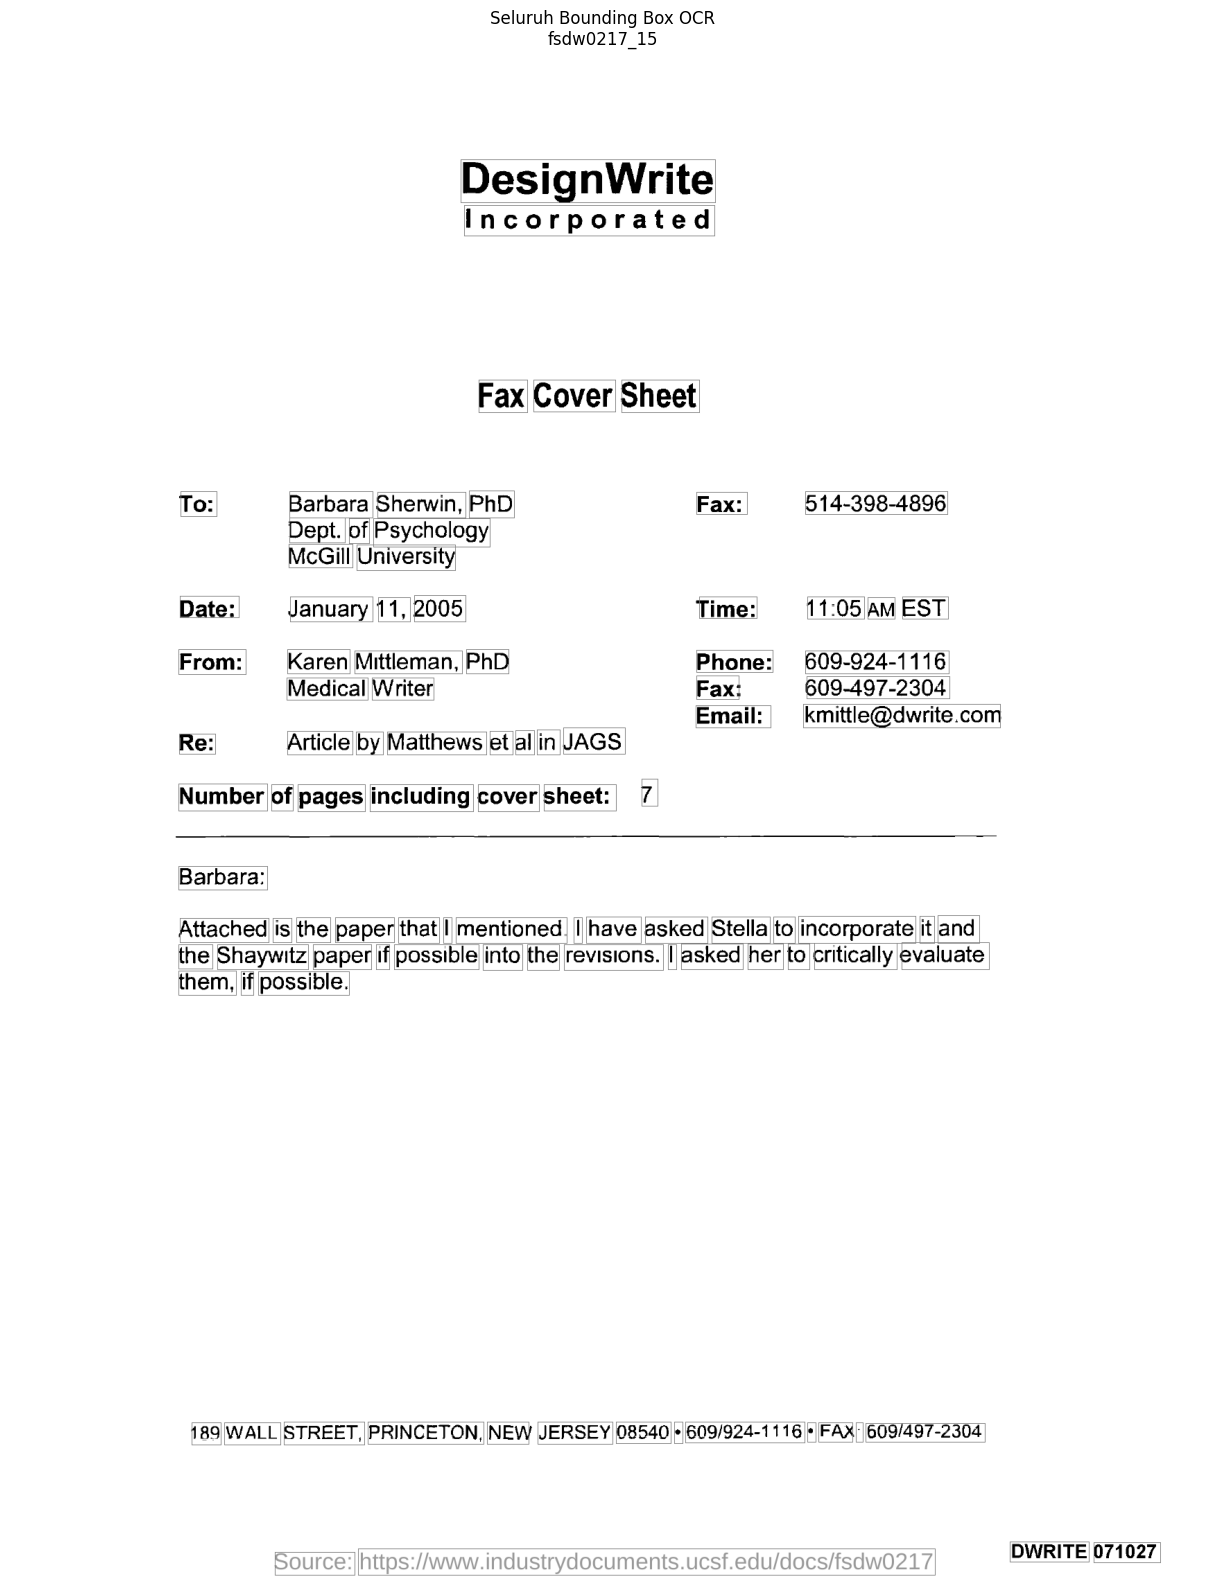

In [7]:
ocr_visualization = draw_ocr_boxes(
    image=image,
    words=words,
    color="gray",
    width=1
)

plt.figure(figsize=(14, 16))
plt.imshow(ocr_visualization)
plt.axis("off")
plt.title(f"Seluruh Bounding Box OCR\n{selected_doc_id}")
plt.tight_layout()
plt.show()

## Answer matching

In [8]:
match_result = match_answer(
    words=words,
    answer_candidates=answer_candidates
)

if match_result["matched"]:
    normalized_answer_box = normalize_box(
        box=match_result["box"],
        image_width=image.width,
        image_height=image.height
    )
else:
    normalized_answer_box = None

matched_words = " ".join(word["text"] for word in match_result["words"])

match_summary_df = pd.DataFrame({
    "metric": ["Matched", "Answer", "Matched words", "Word indices", "Pixel bounding box", "Normalized bounding box"],
    "nilai": [match_result["matched"], match_result["answer"], matched_words, match_result["word_indices"], match_result["box"], normalized_answer_box]
})

display(match_summary_df)

,metric,nilai
0,Matched,True
1,Answer,"Karen Mittleman, PhD"
2,Matched words,"Karen Mittleman, PhD"
3,Word indices,"[25, 26, 27]"
4,Pixel bounding box,"[400.0, 862.0, 719.0, 897.0]"
5,Normalized bounding box,"[234, 391, 420, 407]"


## Answer bounding box

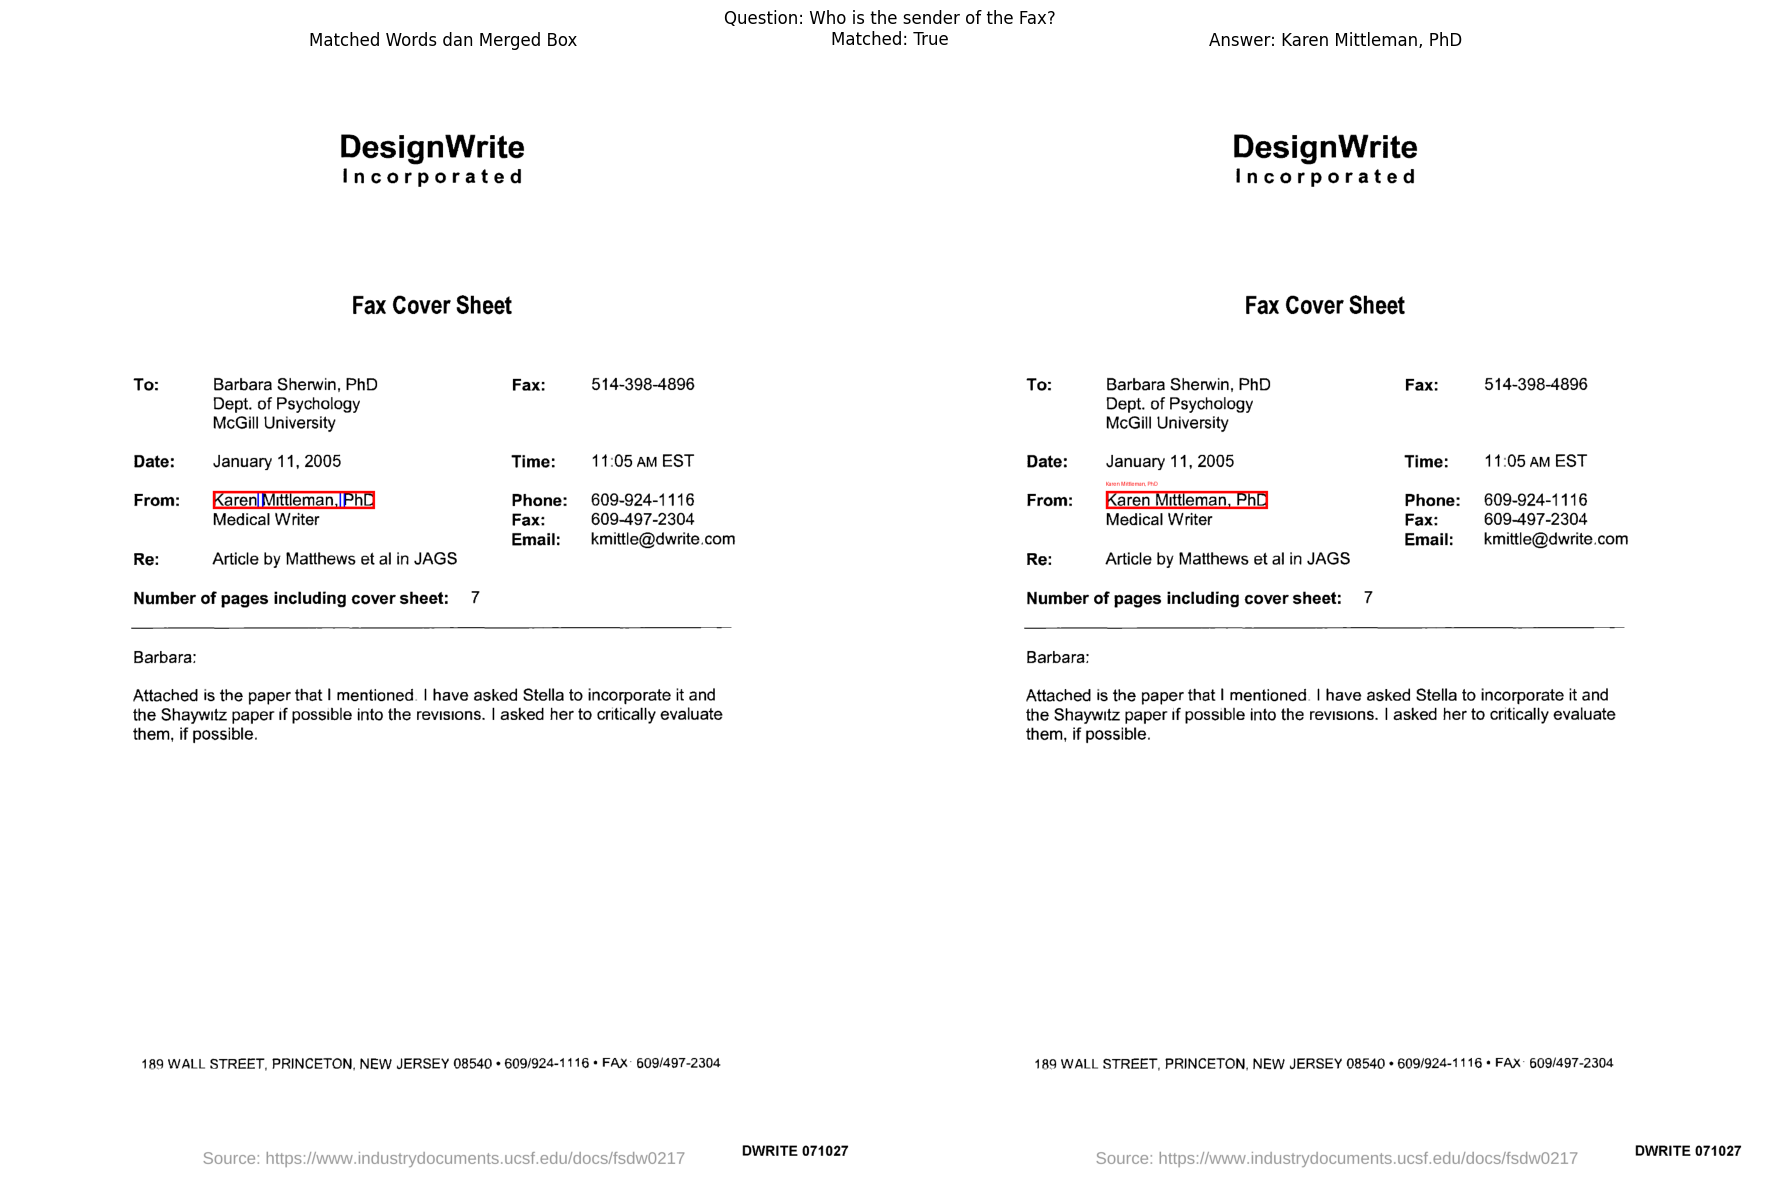

In [9]:
answer_words_visualization = draw_answer_words(
    image=image,
    matched_words=match_result["words"]
)

answer_box_visualization = draw_answer_box(
    image=image,
    answer_box=match_result["box"],
    answer_text=match_result["answer"]
)

fig, axes = plt.subplots(1, 2, figsize=(18, 12))
axes[0].imshow(answer_words_visualization)
axes[0].axis("off")
axes[0].set_title("Matched Words dan Merged Box")

axes[1].imshow(answer_box_visualization)
axes[1].axis("off")
axes[1].set_title(f"Answer: {match_result['answer']}")

plt.suptitle(f"Question: {question}\nMatched: {match_result['matched']}")
plt.tight_layout()
plt.show()

# Evaluation

## Answer matching data

In [10]:
ocr_cache = {}
matching_rows = []

for index, (split, record) in enumerate(all_records):
    current_ocr_path = find_file(ocr_index, record)

    if current_ocr_path is None:
        matching_rows.append({
            "split": split,
            "question_id": get_question_id(record, index),
            "doc_id": get_doc_id(record),
            "question": get_question(record),
            "answers": get_answers(record),
            "ocr_found": False,
            "answer_matched": False,
            "matched_answer": None,
            "matched_words": None,
            "answer_box": None
        })
        continue

    if current_ocr_path not in ocr_cache:
        ocr_cache[current_ocr_path] = load_ocr(current_ocr_path)

    current_ocr = ocr_cache[current_ocr_path]
    result = match_answer(
        words=current_ocr["words"],
        answer_candidates=get_answers(record)
    )

    matching_rows.append({
        "split": split,
        "question_id": get_question_id(record, index),
        "doc_id": get_doc_id(record),
        "question": get_question(record),
        "answers": get_answers(record),
        "ocr_found": True,
        "answer_matched": result["matched"],
        "matched_answer": result["answer"],
        "matched_words": " ".join(word["text"] for word in result["words"]),
        "answer_box": result["box"]
    })

matching_df = pd.DataFrame(matching_rows)

display(matching_df.head())

,split,question_id,doc_id,question,answers,ocr_found,answer_matched,matched_answer,matched_words,answer_box
0,train,11837,3855,What is the name of the company of Mr. Roger ...,[Philip Morris],True,True,Philip Morris,Philip Morris,"[648.0, 218.0, 843.0, 244.0]"
1,train,2813,1603,What is the area code for Godchaux-Henderson S...,[205],True,True,205,205,"[1253.0, 321.0, 1288.0, 351.0]"
2,train,28676,8286,What is the date on the document?,"[june 13, 1979, June 13, 1979]",True,False,None,,None
3,train,25872,7365,what is the mean intake of % of total calories...,[45.0],True,True,45.0,45.0,"[1194.0, 830.0, 1265.0, 862.0]"
4,train,23465,6827,what is the name of the university,"[Vanderbilt University, vanderbilt university]",True,False,None,,None


## Summary

In [11]:
ocr_available_df = matching_df[matching_df["ocr_found"]].copy()

if len(ocr_available_df) > 0:
    match_percentage = ocr_available_df["answer_matched"].mean() * 100
else:
    match_percentage = 0

matching_summary_df = pd.DataFrame({
    "metric": ["Jumlah pertanyaan", "OCR tersedia", "OCR tidak tersedia", "Jawaban cocok", "Jawaban tidak cocok", "Persentase matching"],
    "nilai": [len(matching_df), matching_df["ocr_found"].sum(), (~matching_df["ocr_found"]).sum(), ocr_available_df["answer_matched"].sum(), (~ocr_available_df["answer_matched"]).sum(), match_percentage]
})

display(matching_summary_df.round(2))

,metric,nilai
0,Jumlah pertanyaan,600.00
1,OCR tersedia,600.00
2,OCR tidak tersedia,0.00
3,Jawaban cocok,523.00
4,Jawaban tidak cocok,77.00
5,Persentase matching,87.17


## Match distribution

,status,count
0,Cocok,523
1,Tidak cocok,77


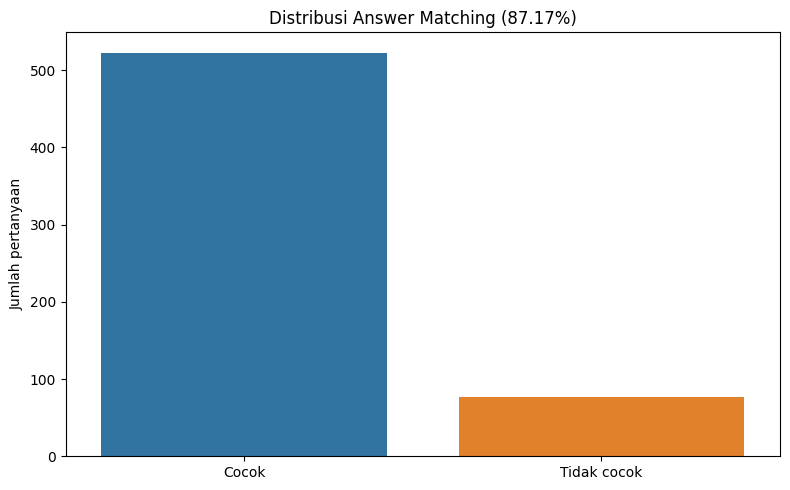

In [12]:
match_status_df = (
    ocr_available_df["answer_matched"]
    .map({True: "Cocok", False: "Tidak cocok"})
    .value_counts()
    .rename_axis("status")
    .reset_index(name="count")
)

display(match_status_df)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=match_status_df,
    x="status",
    y="count",
    hue="status",
    legend=False
)
plt.title(f"Distribusi Answer Matching ({match_percentage:.2f}%)")
plt.xlabel("")
plt.ylabel("Jumlah pertanyaan")
plt.tight_layout()
plt.show()